In [1]:
import os
import shelve
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from glob import glob
from tqdm.auto import tqdm

In [3]:
import numpy as np

### This notebook is only to be executed after running the machine learning experiments! It will not run otherwise.

In [4]:
with shelve.open('cache', flag='r', writeback=False) as shf:
    print(list(shf.keys()))
    r = shf['all;5']

['part_datas_5', 'all;5', 'imu_l;5', 'imu_r;5', 'imu_l+imu_r;5', 'a;5', 'imu_r+a;5', 'imu_l+imu_r+a;5', 'part_datas_10', 'all;10', 'imu_l;10', 'imu_r;10', 'imu_l+imu_r;10', 'a;10', 'imu_r+a;10', 'a+h;5', 'imu_l+imu_r+h;5', 'imu_l+imu_r+a;10', 'a+h;10', 'imu_l+imu_r+h;10', 'h;5', 'h;10', 'part_datas_20', 'all;20']


In [5]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

KERNEL = np.array([0.1, 0.2, 0.4, 0.2, 0.1])
HALF_K = len(KERNEL) // 2

def smooth_predictions(preds, num_classes):
    preds = np.asarray(preds)
    smoothed = []

    for i in range(len(preds)):
        class_scores = np.zeros(num_classes)
        weight_sum = 0.0

        for k in range(len(KERNEL)):
            idx = i + k - HALF_K
            if 0 <= idx < len(preds):
                w = KERNEL[k]
                class_scores[preds[idx]] += w
                weight_sum += w

        # normalize (important for edges)
        if weight_sum > 0:
            class_scores /= weight_sum

        smoothed.append(np.argmax(class_scores))

    return np.array(smoothed)

In [6]:
def calc_metrics(all_preds, all_true, test_order):
    r = []
    for i, (p, t, s) in enumerate(zip(all_preds, all_true, test_order)):
        p = le.inverse_transform(p)
        t = le.inverse_transform(t)
        r.append([f1_score(t, p, average="macro"), f1_score(t, p, average="weighted"), accuracy_score(p, t), s.zfill(2)])
    return r, f1_score(np.concat(all_true), np.concat(all_preds), average="macro")


def calc_metrics_sm(all_preds, all_true, test_order):
    r = []
    num_classes = len(le.classes_)
    for i, (p, t, s) in enumerate(zip(all_preds, all_true, test_order)):
        # apply smoothing BEFORE inverse transform
        p = smooth_predictions(p, num_classes)

        p = le.inverse_transform(p)
        t = le.inverse_transform(t)

        r.append([
            f1_score(t, p, average="macro"),
            f1_score(t, p, average="weighted"),
            accuracy_score(p, t),
            s.zfill(2)
        ])
    return r, f1_score(np.concatenate(all_true), np.concatenate(all_preds), average="macro")

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_order = [
    "Null",
    "Floor cleaning",
    "Making tea",
    "Vacuum Cleaning",
    "Window cleaning",
    "Brushing teeth",
    "Washing dishes",
    "Cutting vegetables",
    "Putting away the dishes",
    "Cleaning out the dishwasher",
    "Watering plant",
    "Cleaning table",
    "Washing hands",
    "Drinking",
    "Cream hands",
    "Disinfecting hands"
]
print(len(label_order))
le.fit(label_order)

16


LabelEncoder()

In [8]:
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay

In [9]:
metr_dfs = []
preds = []
labels = []
orders = []
cfgs = []
with shelve.open("cache") as shf:
    for key in shf.keys():
        if "part_datas" in key or shf[key]=="running":
            continue
        if ";" in key:
            res = shf[key]
            preds.append(res[0])
            labels.append(res[1])
            orders.append(res[2])
            cfgs.append(key)
            metrics, f1_macro = calc_metrics(*res)
            metr_df = pd.DataFrame(metrics, columns=["F1-Score (macro)", "F1-score (weighted)", "Accuracy", "Participant"])
            s_cfg_str, ws = key.split(";")
            metr_df["window size"] = ws.zfill(2)
            metr_df["sensor_config"] = s_cfg_str
            metr_dfs.append(metr_df)
full_results_df = pd.concat(metr_dfs)
full_results_df["Participant | Window Size"] = "P" + full_results_df.Participant + " | " + full_results_df["window size"].astype(str)  + "s"


In [10]:
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

def best_dummy_macro_f1(y_true):
    strategies = ["most_frequent", "prior", "stratified", "uniform"]
    results = {}

    X_dummy = np.zeros((len(y_true), 1))  # dummy feature matrix

    for strat in strategies:
        clf = DummyClassifier(strategy=strat, random_state=42)
        clf.fit(X_dummy, y_true)
        y_pred = clf.predict(X_dummy)
        score = f1_score(y_true, y_pred, average="macro")
        results[strat] = score

    # Also test constant prediction for each class explicitly
    classes = np.unique(y_true)
    for c in classes:
        clf = DummyClassifier(strategy="constant", constant=c)
        clf.fit(X_dummy, y_true)
        y_pred = clf.predict(X_dummy)
        score = f1_score(y_true, y_pred, average="macro")
        results[f"constant_{c}"] = score

    best_strategy = max(results, key=results.get)
    return best_strategy, results[best_strategy], results

# Example usage
y_true = np.concatenate(labels[0])
best, best_score, all_results = best_dummy_macro_f1(y_true)

print("Best strategy:", best)
print("Best macro F1:", best_score)
print("All results:", all_results)

Best strategy: stratified
Best macro F1: 0.06193665122829504
All results: {'most_frequent': 0.015716067864271457, 'prior': 0.015716067864271457, 'stratified': 0.06193665122829504, 'uniform': 0.05988046198205911, 'constant_0': 0.008159944515578318, 'constant_1': 0.006104777415852335, 'constant_2': 0.004749511321956469, 'constant_3': 0.0027955717251076937, 'constant_4': 0.006869228445671873, 'constant_5': 0.001647478934799261, 'constant_6': 0.0036487654594618557, 'constant_7': 0.011096259465756845, 'constant_8': 0.010708694290783843, 'constant_9': 0.015716067864271457, 'constant_10': 0.006897258353286309, 'constant_11': 0.010584498359559484, 'constant_12': 0.007937610912745077, 'constant_13': 0.004237615245489435, 'constant_14': 0.005322520710835209, 'constant_15': 0.009437397104141163}


In [11]:
y_true = np.concatenate(labels[12])
best, best_score, all_results = best_dummy_macro_f1(y_true)

print("Best strategy:", best)
print("Best macro F1:", best_score)
print("All results:", all_results)

Best strategy: stratified
Best macro F1: 0.06335847199735968
All results: {'most_frequent': 0.011648986864459454, 'prior': 0.011648986864459454, 'stratified': 0.06335847199735968, 'uniform': 0.05999537527789963, 'constant_0': 0.00859079109749351, 'constant_1': 0.006348948167425721, 'constant_2': 0.005190084092501752, 'constant_3': 0.003259902091677793, 'constant_4': 0.0072529269972451795, 'constant_5': 0.001967707115228929, 'constant_6': 0.004040459871766527, 'constant_7': 0.011648986864459454, 'constant_8': 0.011063559498521388, 'constant_9': 0.009801650804345995, 'constant_10': 0.00732384066075884, 'constant_11': 0.011106253643101008, 'constant_12': 0.008337598089389288, 'constant_13': 0.004863855950812472, 'constant_14': 0.005759339174403906, 'constant_15': 0.009966358284272498}


In [12]:
palette = sns.color_palette("husl", 18)
reordered = palette[::2] + palette[1::2]

In [13]:
full_results_df[(full_results_df["window size"] == "05") & (full_results_df.sensor_config == "all")].describe()

,F1-Score (macro),F1-score (weighted),Accuracy
count,20.000000,20.000000,20.000000
mean,0.754335,0.789397,0.788954
std,0.063018,0.062067,0.062756
min,0.587356,0.614052,0.606550
25%,0.721630,0.755536,0.757626
50%,0.764970,0.803970,0.803150
75%,0.787988,0.817342,0.815889
max,0.845661,0.883389,0.882927


In [14]:
full_results_df[(full_results_df["window size"] == "05") & (full_results_df.sensor_config == "imu_l+imu_r")].describe()

,F1-Score (macro),F1-score (weighted),Accuracy
count,20.000000,20.000000,20.000000
mean,0.618640,0.638882,0.639439
std,0.064171,0.073041,0.073116
min,0.450948,0.460691,0.448765
25%,0.592066,0.597484,0.600248
50%,0.626486,0.646596,0.647053
75%,0.659064,0.691788,0.687428
max,0.726797,0.773922,0.769268


In [15]:
sns.set_style("whitegrid")

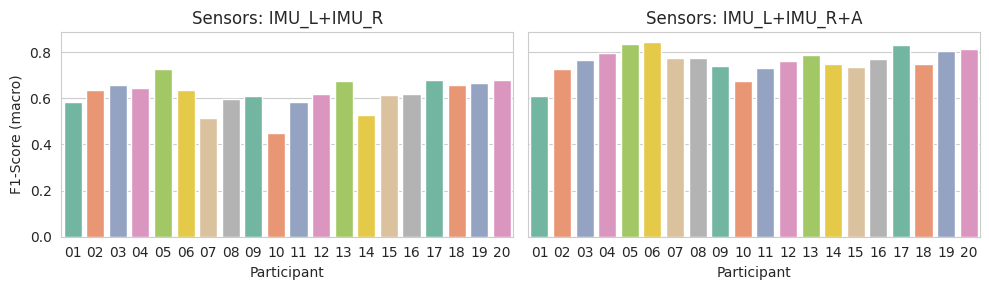

In [16]:
fig, axes = plt.subplots(1,2, figsize=(10,3), sharey=True)

for i, ax in enumerate(axes):
    ax.set_title(f"Sensors: {['imu_l+imu_r', 'imu_l+imu_r+a'][i].upper()}")

sns.barplot(data=full_results_df[(full_results_df["window size"] == "05") & (full_results_df.sensor_config == "imu_l+imu_r")],
            x="Participant", hue="Participant", y="F1-Score (macro)", palette="Set2", legend=False, ax=axes[0])
sns.barplot(data=full_results_df[(full_results_df["window size"] == "05") & (full_results_df.sensor_config == "imu_l+imu_r+a")],
            x="Participant", hue="Participant", y="F1-Score (macro)", palette="Set2", legend=False, ax=axes[1])
plt.tight_layout()
plt.savefig("res_per_part.pdf", bbox_inches="tight")

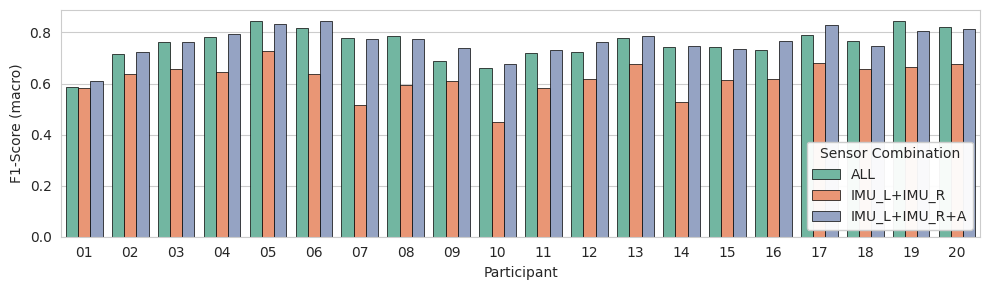

In [17]:
fig, ax = plt.subplots(figsize=(10,3))
rel_sens_df = full_results_df[(full_results_df["window size"] == "05") & ((full_results_df.sensor_config =="imu_l+imu_r") | (full_results_df.sensor_config == "all")| (full_results_df.sensor_config == "imu_l+imu_r+a"))]
sns.barplot(data=rel_sens_df,
            x="Participant", hue="sensor_config", y="F1-Score (macro)", palette="Set2", ax=ax,linewidth=0.5, edgecolor="black")
L = plt.legend(loc="lower right", title="Sensor Combination", framealpha=.95)
for t in L.get_texts():
    t.set_text(t.get_text().upper())
plt.tight_layout()
plt.savefig("res_per_part_alt.pdf", bbox_inches="tight")

In [18]:
best_df = full_results_df[(full_results_df["window size"] == "05") & (full_results_df.sensor_config == "imu_l+imu_r+a")]

In [19]:
best_df

,F1-Score (macro),F1-score (weighted),Accuracy,Participant,window size,sensor_config,Participant | Window Size
0,0.609517,0.620139,0.603858,01,05,imu_l+imu_r+a,P01 | 05s
1,0.724379,0.756259,0.765595,02,05,imu_l+imu_r+a,P02 | 05s
2,0.764542,0.801221,0.802326,03,05,imu_l+imu_r+a,P03 | 05s
3,0.795459,0.807497,0.809460,04,05,imu_l+imu_r+a,P04 | 05s
4,0.834624,0.876341,0.874634,05,05,imu_l+imu_r+a,P05 | 05s
5,0.844308,0.865958,0.865816,06,05,imu_l+imu_r+a,P06 | 05s
6,0.772427,0.798451,0.797569,07,05,imu_l+imu_r+a,P07 | 05s
7,0.775172,0.809308,0.807920,08,05,imu_l+imu_r+a,P08 | 05s
8,0.737378,0.790202,0.794005,09,05,imu_l+imu_r+a,P09 | 05s
9,0.676429,0.716121,0.718207,10,05,imu_l+imu_r+a,P10 | 05s


In [20]:
full_results_df

,F1-Score (macro),F1-score (weighted),Accuracy,Participant,window size,sensor_config,Participant | Window Size
0,0.587356,0.614052,0.606550,01,05,all,P01 | 05s
1,0.716968,0.750288,0.758034,02,05,all,P02 | 05s
2,0.761992,0.807783,0.811949,03,05,all,P03 | 05s
3,0.783083,0.800356,0.801874,04,05,all,P04 | 05s
4,0.845661,0.883389,0.882927,05,05,all,P05 | 05s
...,...,...,...,...,...,...,...
15,0.115856,0.124556,0.156222,16,10,h,P16 | 10s
16,0.134129,0.145346,0.192837,17,10,h,P17 | 10s
17,0.128155,0.132588,0.157635,18,10,h,P18 | 10s
18,0.108316,0.124346,0.163343,19,10,h,P19 | 10s


In [21]:
wide_df = full_results_df[full_results_df["window size"]=="05"].pivot_table(
    index="Participant",
    columns="sensor_config",
    values=["F1-Score (macro)", "F1-score (weighted)", "Accuracy"]
)

# Put sensor_config as the outer level
wide_df = wide_df.swaplevel(0, 1, axis=1).sort_index(axis=1)

wide_df=wide_df.T


In [22]:
new_cols = pd.MultiIndex.from_tuples(
    [(str(l0).upper(), l1) for l0, l1 in wide_df.index]
)

wide_df.index = new_cols

In [23]:
[(str(l0).upper(), l1) for l0, l1 in wide_df.columns]

[('0', '1'),
 ('0', '2'),
 ('0', '3'),
 ('0', '4'),
 ('0', '5'),
 ('0', '6'),
 ('0', '7'),
 ('0', '8'),
 ('0', '9'),
 ('1', '0'),
 ('1', '1'),
 ('1', '2'),
 ('1', '3'),
 ('1', '4'),
 ('1', '5'),
 ('1', '6'),
 ('1', '7'),
 ('1', '8'),
 ('1', '9'),
 ('2', '0')]

In [24]:
new_cols

MultiIndex([(            'A',            'Accuracy'),
            (            'A',    'F1-Score (macro)'),
            (            'A', 'F1-score (weighted)'),
            (          'A+H',            'Accuracy'),
            (          'A+H',    'F1-Score (macro)'),
            (          'A+H', 'F1-score (weighted)'),
            (          'ALL',            'Accuracy'),
            (          'ALL',    'F1-Score (macro)'),
            (          'ALL', 'F1-score (weighted)'),
            (            'H',            'Accuracy'),
            (            'H',    'F1-Score (macro)'),
            (            'H', 'F1-score (weighted)'),
            (        'IMU_L',            'Accuracy'),
            (        'IMU_L',    'F1-Score (macro)'),
            (        'IMU_L', 'F1-score (weighted)'),
            (  'IMU_L+IMU_R',            'Accuracy'),
            (  'IMU_L+IMU_R',    'F1-Score (macro)'),
            (  'IMU_L+IMU_R', 'F1-score (weighted)'),
            ('IMU_L+IMU_R+A'

In [25]:
import pandas as pd


latex_str = wide_df.to_latex(
    float_format="%.2f",
    multicolumn=True,
    multirow=True
)
latex_str = latex_str.replace(
    "\\begin{tabular}",
    "\\resizebox{\\textwidth}{!}{\\begin{tabular}"
).replace(
    "\\end{tabular}",
    "\\end{tabular}}"
).replace("_", "\\_")

print(latex_str)

\resizebox{\textwidth}{!}{\begin{tabular}{llrrrrrrrrrrrrrrrrrrrr}
\toprule
 & Participant & 01 & 02 & 03 & 04 & 05 & 06 & 07 & 08 & 09 & 10 & 11 & 12 & 13 & 14 & 15 & 16 & 17 & 18 & 19 & 20 \\
\midrule
\multirow[t]{3}{*}{A} & Accuracy & 0.51 & 0.69 & 0.74 & 0.75 & 0.80 & 0.81 & 0.79 & 0.81 & 0.73 & 0.68 & 0.67 & 0.64 & 0.75 & 0.77 & 0.71 & 0.75 & 0.78 & 0.76 & 0.82 & 0.81 \\
 & F1-Score (macro) & 0.50 & 0.64 & 0.69 & 0.72 & 0.77 & 0.78 & 0.76 & 0.77 & 0.67 & 0.62 & 0.64 & 0.60 & 0.72 & 0.73 & 0.68 & 0.71 & 0.75 & 0.72 & 0.79 & 0.74 \\
 & F1-score (weighted) & 0.52 & 0.68 & 0.75 & 0.75 & 0.80 & 0.81 & 0.80 & 0.81 & 0.73 & 0.67 & 0.67 & 0.64 & 0.75 & 0.76 & 0.70 & 0.75 & 0.78 & 0.77 & 0.82 & 0.81 \\
\cline{1-22}
\multirow[t]{3}{*}{A+H} & Accuracy & 0.52 & 0.66 & 0.77 & 0.77 & 0.81 & 0.82 & 0.79 & 0.80 & 0.72 & 0.63 & 0.71 & 0.67 & 0.75 & 0.76 & 0.70 & 0.72 & 0.80 & 0.76 & 0.79 & 0.82 \\
 & F1-Score (macro) & 0.49 & 0.60 & 0.72 & 0.74 & 0.76 & 0.79 & 0.76 & 0.76 & 0.66 & 0.57 & 0.67 & 0.6

In [26]:
best_df.describe()

,F1-Score (macro),F1-score (weighted),Accuracy
count,20.000000,20.000000,20.000000
mean,0.762977,0.794937,0.794131
std,0.055225,0.058029,0.060039
min,0.609517,0.620139,0.603858
25%,0.736545,0.769561,0.770346
50%,0.766235,0.799727,0.796697
75%,0.798236,0.827953,0.826429
max,0.844308,0.876341,0.874634


In [27]:
best_df.sort_values(by="F1-Score (macro)")

,F1-Score (macro),F1-score (weighted),Accuracy,Participant,window size,sensor_config,Participant | Window Size
0,0.609517,0.620139,0.603858,01,05,imu_l+imu_r+a,P01 | 05s
9,0.676429,0.716121,0.718207,10,05,imu_l+imu_r+a,P10 | 05s
1,0.724379,0.756259,0.765595,02,05,imu_l+imu_r+a,P02 | 05s
10,0.731466,0.760881,0.760187,11,05,imu_l+imu_r+a,P11 | 05s
14,0.734044,0.758963,0.758853,15,05,imu_l+imu_r+a,P15 | 05s
8,0.737378,0.790202,0.794005,09,05,imu_l+imu_r+a,P09 | 05s
13,0.746349,0.788417,0.789072,14,05,imu_l+imu_r+a,P14 | 05s
17,0.747688,0.797617,0.792425,18,05,imu_l+imu_r+a,P18 | 05s
11,0.762067,0.772455,0.771930,12,05,imu_l+imu_r+a,P12 | 05s
2,0.764542,0.801221,0.802326,03,05,imu_l+imu_r+a,P03 | 05s


/tmp/ipykernel_29577/2815322680.py:3: UserWarning: 
The palette list has fewer values (18) than needed (40) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=full_results_df.sort_values(by="Participant"), hue="Participant | Window Size", x="sensor_config", y="F1-Score (macro)", ax=ax,
/tmp/ipykernel_29577/2815322680.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


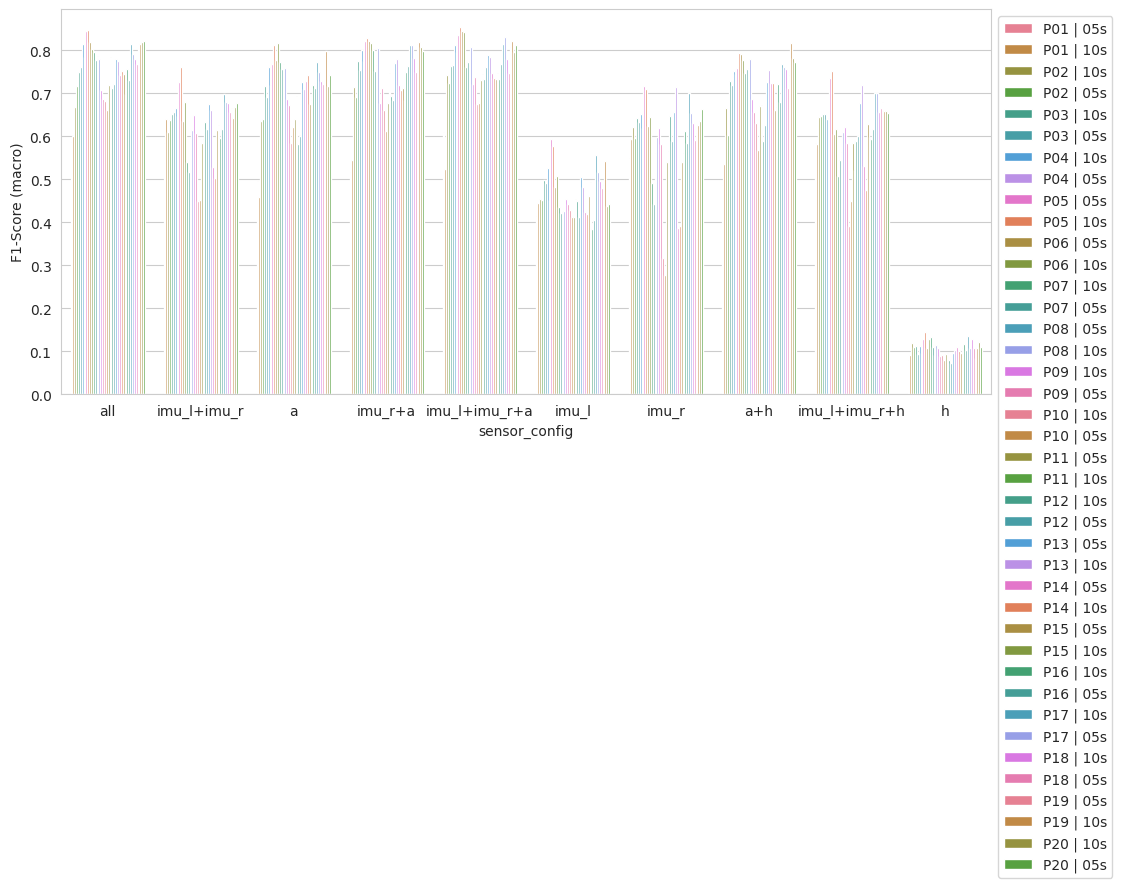

In [28]:
fig, ax = plt.subplots(figsize=(12,5))

sns.barplot(data=full_results_df.sort_values(by="Participant"), hue="Participant | Window Size", x="sensor_config", y="F1-Score (macro)", ax=ax,
           palette=reordered)

plt.legend(bbox_to_anchor=(1,1))

plt.tight_layout()
plt.savefig("res_per_subj.pdf")

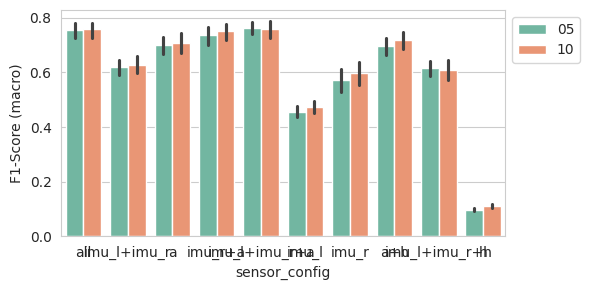

In [29]:
fig, ax = plt.subplots(figsize=(6,3))

sns.barplot(data=full_results_df.sort_values(by="Participant"), hue="window size", x="sensor_config", y="F1-Score (macro)", ax=ax, palette="Set2")

plt.legend(bbox_to_anchor=(1,1))

plt.tight_layout()
plt.savefig("res_per_ws.pdf")

In [30]:
res_order = ["h", "imu_l", "imu_r", "imu_l+imu_r", "imu_l+imu_r+h", "a", "a+h", "imu_r+a", "imu_l+imu_r+a", "all"]

In [31]:
def bold_max(s):
    is_max = s == s.max()
    return ["font-weight: bold;" if v else "" for v in is_max]

In [32]:
df = full_results_df.groupby(["sensor_config", "window size"]).mean(numeric_only=True).unstack("window size").swaplevel(0, 1, axis=1).sort_index(axis=1).loc[res_order]
df.index = df.index = [x.upper() for x in df.index]
styler = (
    df.style
    .format("{:.3f}", escape="latex")          # controls numeric display
    .apply(bold_max, axis=0) # controls bolding
)

In [33]:
styler

In [34]:
latex = styler.to_latex(
    hrules=True,
    multicol_align="c",
    caption="Model performance by sensor configuration and window size",
    label="tab:results",      # ← THIS is what you want
    convert_css=True
)
print(latex.replace("_", "\\_").replace("-Score", "").replace("-score", ""))
#with open("table.tex", "w") as f:
#    f.write(latex)

\begin{table}
\caption{Model performance by sensor configuration and window size}
\label{tab:results}
\begin{tabular}{lrrrrrr}
\toprule
window size & \multicolumn{3}{c}{05} & \multicolumn{3}{c}{10} \\
 & Accuracy & F1 (macro) & F1 (weighted) & Accuracy & F1 (macro) & F1 (weighted) \\
\midrule
H & 0.143 & 0.098 & 0.117 & 0.150 & 0.112 & 0.121 \\
IMU\_L & 0.475 & 0.456 & 0.473 & 0.494 & 0.473 & 0.490 \\
IMU\_R & 0.599 & 0.570 & 0.598 & 0.623 & 0.598 & 0.622 \\
IMU\_L+IMU\_R & 0.639 & 0.619 & 0.639 & 0.652 & 0.628 & 0.651 \\
IMU\_L+IMU\_R+H & 0.638 & 0.617 & 0.638 & 0.634 & 0.609 & 0.634 \\
A & 0.738 & 0.700 & 0.738 & 0.749 & 0.708 & 0.749 \\
A+H & 0.736 & 0.696 & 0.735 & 0.756 & 0.717 & 0.757 \\
IMU\_R+A & 0.771 & 0.736 & 0.772 & 0.781 & 0.750 & 0.783 \\
IMU\_L+IMU\_R+A & \bfseries 0.794 & \bfseries 0.763 & \bfseries 0.795 & \bfseries 0.791 & \bfseries 0.760 & \bfseries 0.794 \\
ALL & 0.789 & 0.754 & 0.789 & 0.789 & 0.758 & 0.791 \\
\bottomrule
\end{tabular}
\end{table}



In [35]:
full_results_df[full_results_df["window size"] == "05"].groupby("sensor_config").mean(numeric_only=True)

,F1-Score (macro),F1-score (weighted),Accuracy
sensor_config,,,
a,0.699550,0.737885,0.738263
a+h,0.695618,0.735111,0.736438
all,0.754335,0.789397,0.788954
h,0.098108,0.117423,0.143072
imu_l,0.456171,0.473065,0.475306
imu_l+imu_r,0.618640,0.638882,0.639439
imu_l+imu_r+a,0.762977,0.794937,0.794131
imu_l+imu_r+h,0.617201,0.638060,0.638379
imu_r,0.570423,0.597926,0.599417


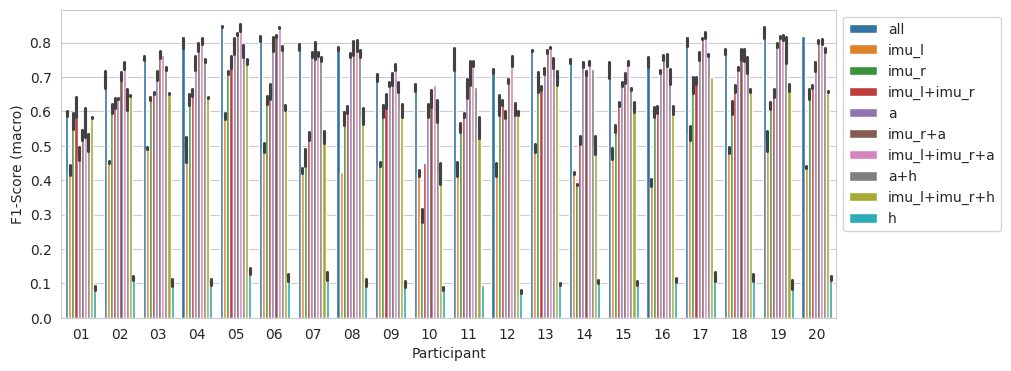

In [36]:
plt.figure(figsize=(10,4))

sns.barplot(data=full_results_df, x="Participant", hue="sensor_config", y="F1-Score (macro)")
plt.legend(bbox_to_anchor=(1,1))

In [37]:
from scipy.stats import normaltest

In [38]:
F1_all = full_results_df.groupby(["Participant", "sensor_config"]).mean(numeric_only=True).loc[slice(None), 'all', :]["F1-Score (macro)"].to_numpy()

In [39]:
F1_noH = full_results_df.groupby(["Participant", "sensor_config"]).mean(numeric_only=True).loc[slice(None), 'imu_l+imu_r+a', :]["F1-Score (macro)"].to_numpy()

In [40]:
normaltest(F1_all), normaltest(F1_noH)

(NormaltestResult(statistic=np.float64(4.658345707399124), pvalue=np.float64(0.09737625819942931)),
 NormaltestResult(statistic=np.float64(14.170585259359488), pvalue=np.float64(0.0008373297239023628)))

In [41]:
from scipy.stats import levene

levene(F1_all, F1_noH)

LeveneResult(statistic=np.float64(0.10168962182259812), pvalue=np.float64(0.75155767177635))

In [42]:
from scipy.stats import ttest_ind

ttest_ind(F1_all, F1_noH, alternative='greater')

TtestResult(statistic=np.float64(-0.27051048303058944), pvalue=np.float64(0.6058842839749492), df=np.float64(38.0))

In [43]:
from scipy.stats import mannwhitneyu

mannwhitneyu(F1_all, F1_noH, alternative='greater')

MannwhitneyuResult(statistic=np.float64(190.0), pvalue=np.float64(0.6118047472247434))

In [44]:
d = (np.mean(F1_all) - np.mean(F1_noH)) / np.sqrt(
    ((np.std(F1_all, ddof=1)**2 + np.std(F1_noH, ddof=1)**2) / 2)
)
d

np.float64(-0.08554292573289903)

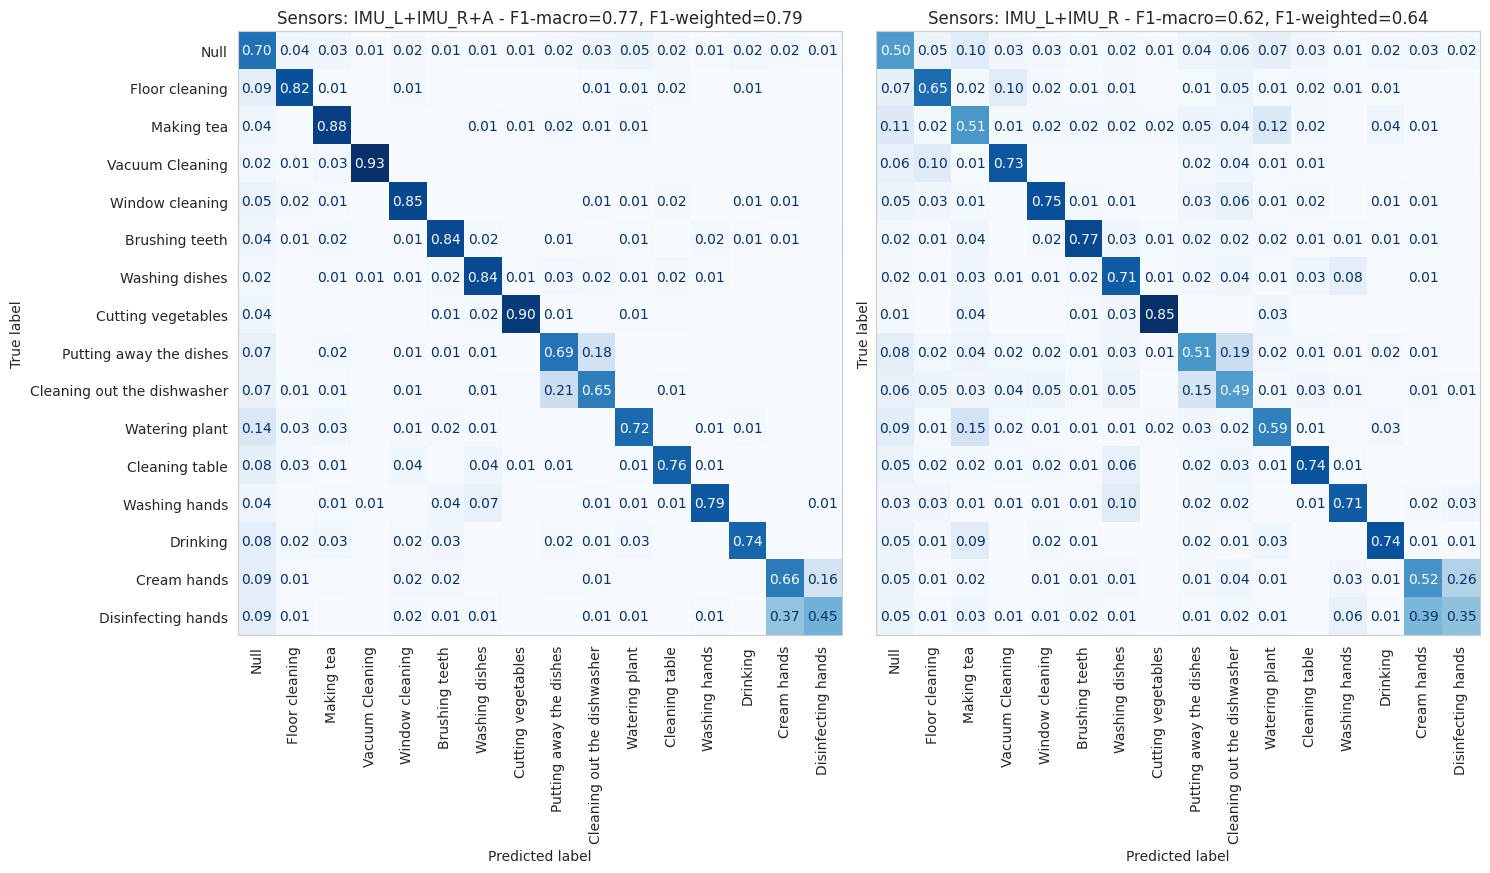

In [45]:
i = 1
fig, axes = plt.subplots(1,2, sharey=True, figsize=(15,22))
for (pred, true, order, key) in zip(preds, labels, orders, cfgs):
    if key not in ["imu_l+imu_r+a;5", "imu_l+imu_r;5"]:
        continue
    pred = le.inverse_transform(np.concat(pred))
    true = le.inverse_transform(np.concat(true))
    disp = ConfusionMatrixDisplay.from_predictions(
        true,
        pred,
        labels=label_order,          # <-- this is the key
        normalize="true",
        ax=axes[i],
        values_format=".2f",
        cmap=plt.cm.Blues,
        colorbar=False
    )

    for text, value in zip(disp.text_.ravel(), disp.confusion_matrix.ravel()):
        if value < 0.005:
            text.set_text('')
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=90)
    f1 = f1_score(true, pred, average="macro")
    f1w = f1_score(true, pred, average="weighted")
    key_text = key.split(";")[0].upper()
    axes[i].set_title(f"Sensors: {key_text} - F1-macro={f1:.2f}, F1-weighted={f1w:.2f}")
    i -= 1
    axes[i].grid(False)
plt.tight_layout()

plt.savefig("conf_two.pdf", bbox_inches="tight")
plt.show()

In [46]:
import os

In [47]:
full_results_df

,F1-Score (macro),F1-score (weighted),Accuracy,Participant,window size,sensor_config,Participant | Window Size
0,0.587356,0.614052,0.606550,01,05,all,P01 | 05s
1,0.716968,0.750288,0.758034,02,05,all,P02 | 05s
2,0.761992,0.807783,0.811949,03,05,all,P03 | 05s
3,0.783083,0.800356,0.801874,04,05,all,P04 | 05s
4,0.845661,0.883389,0.882927,05,05,all,P05 | 05s
...,...,...,...,...,...,...,...
15,0.115856,0.124556,0.156222,16,10,h,P16 | 10s
16,0.134129,0.145346,0.192837,17,10,h,P17 | 10s
17,0.128155,0.132588,0.157635,18,10,h,P18 | 10s
18,0.108316,0.124346,0.163343,19,10,h,P19 | 10s


In [48]:
sorted(cfgs)

['a+h;10',
 'a+h;5',
 'a;10',
 'a;5',
 'all;10',
 'all;5',
 'h;10',
 'h;5',
 'imu_l+imu_r+a;10',
 'imu_l+imu_r+a;5',
 'imu_l+imu_r+h;10',
 'imu_l+imu_r+h;5',
 'imu_l+imu_r;10',
 'imu_l+imu_r;5',
 'imu_l;10',
 'imu_l;5',
 'imu_r+a;10',
 'imu_r+a;5',
 'imu_r;10',
 'imu_r;5']

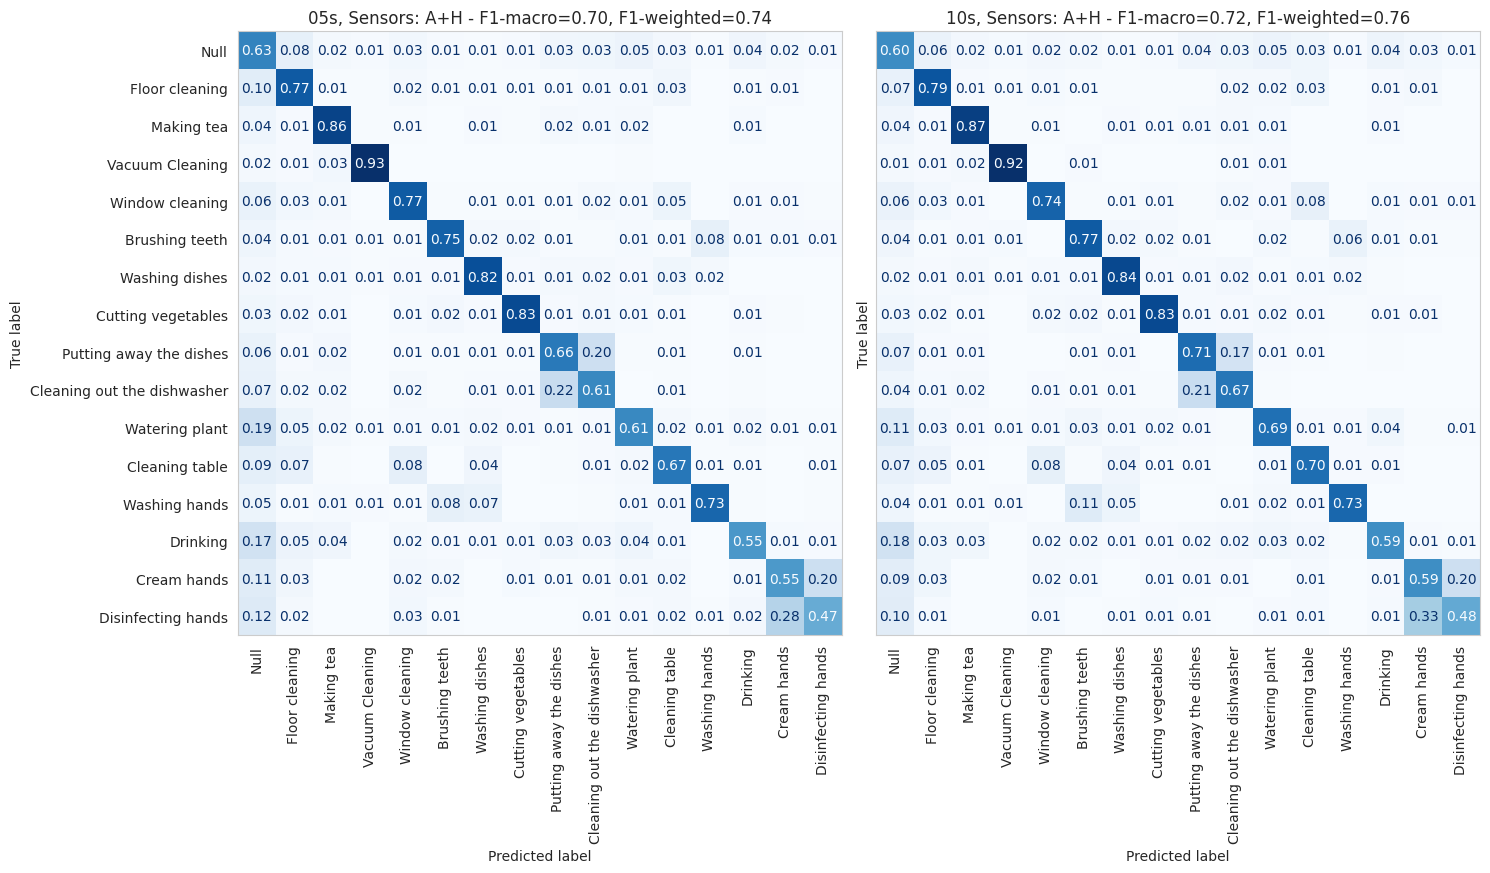

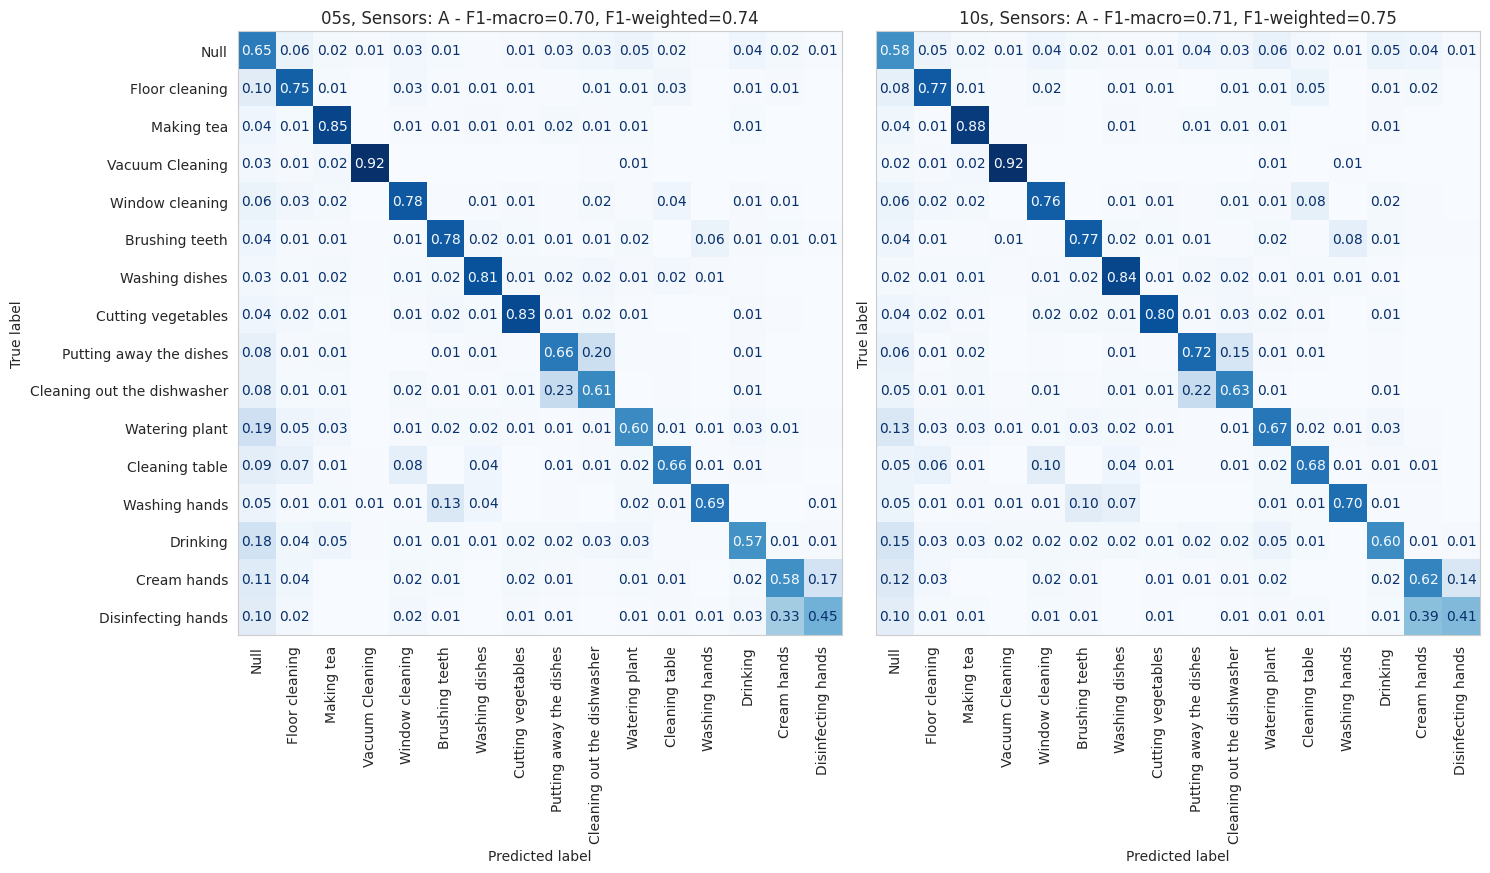

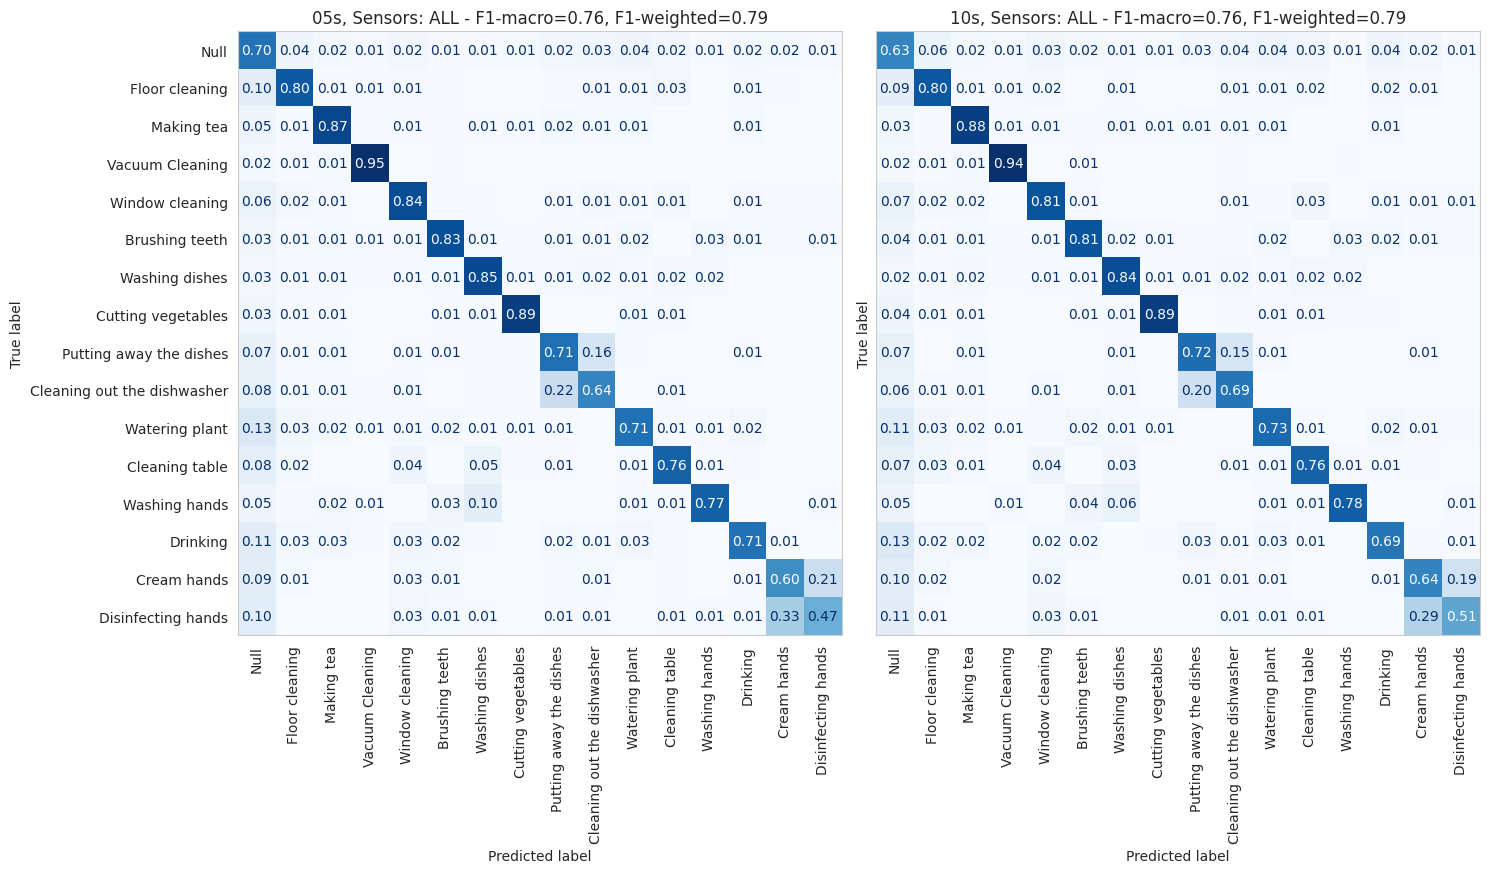

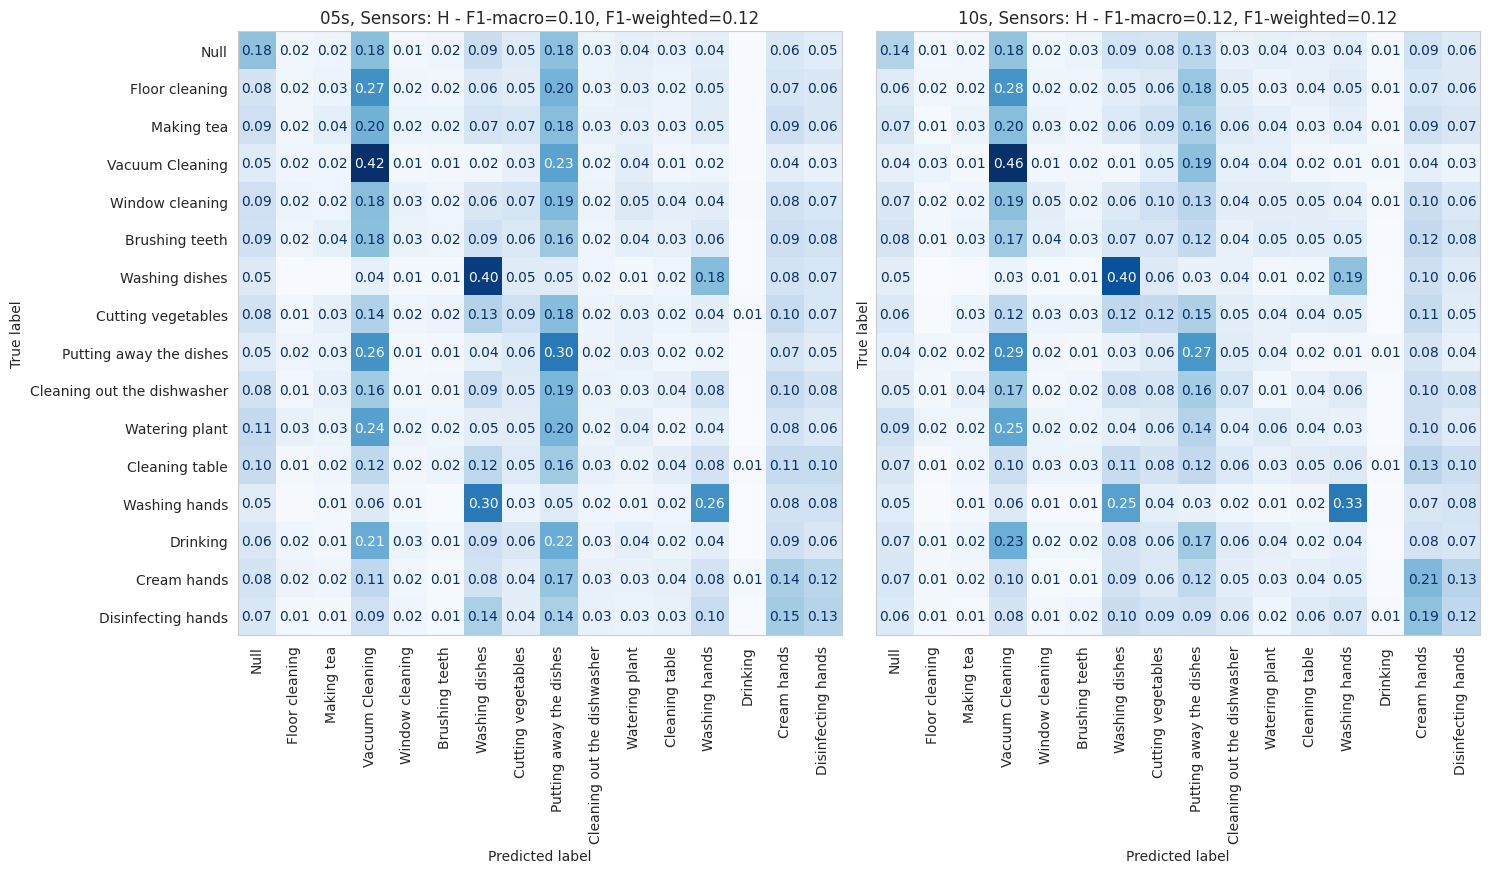

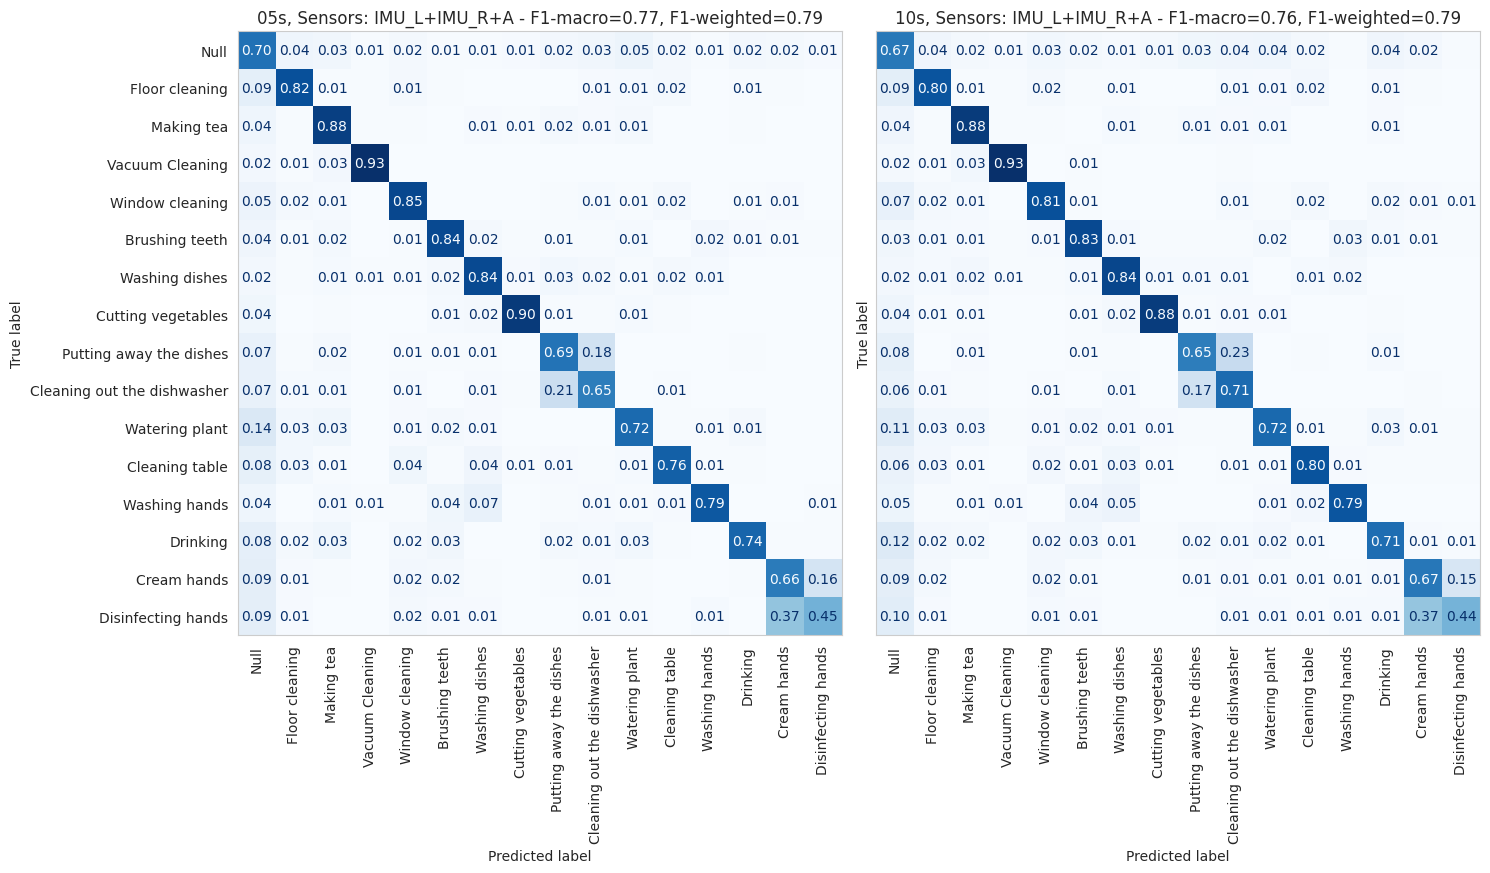

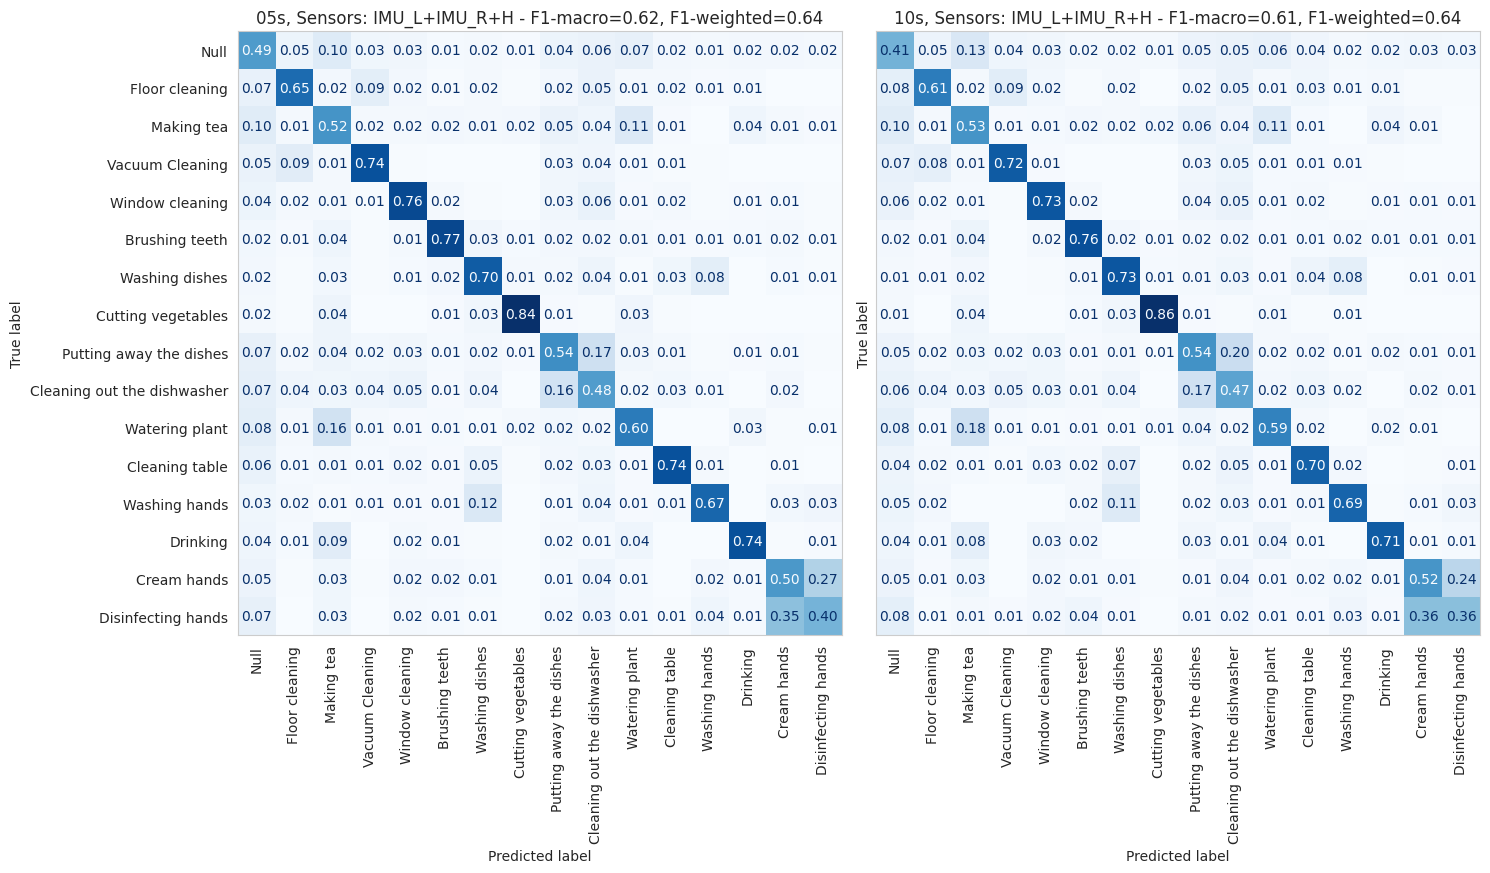

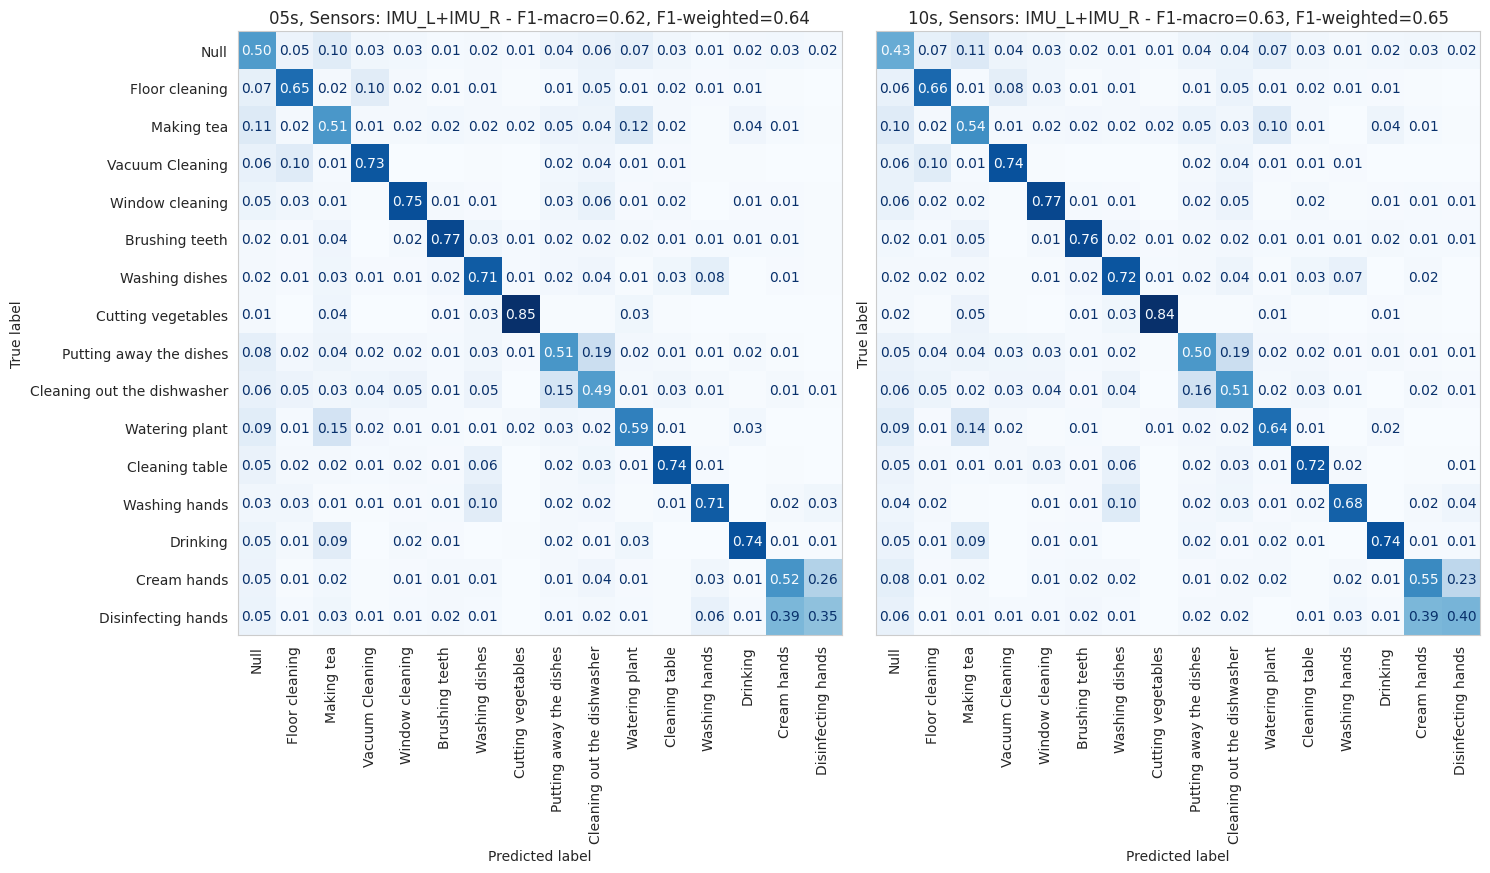

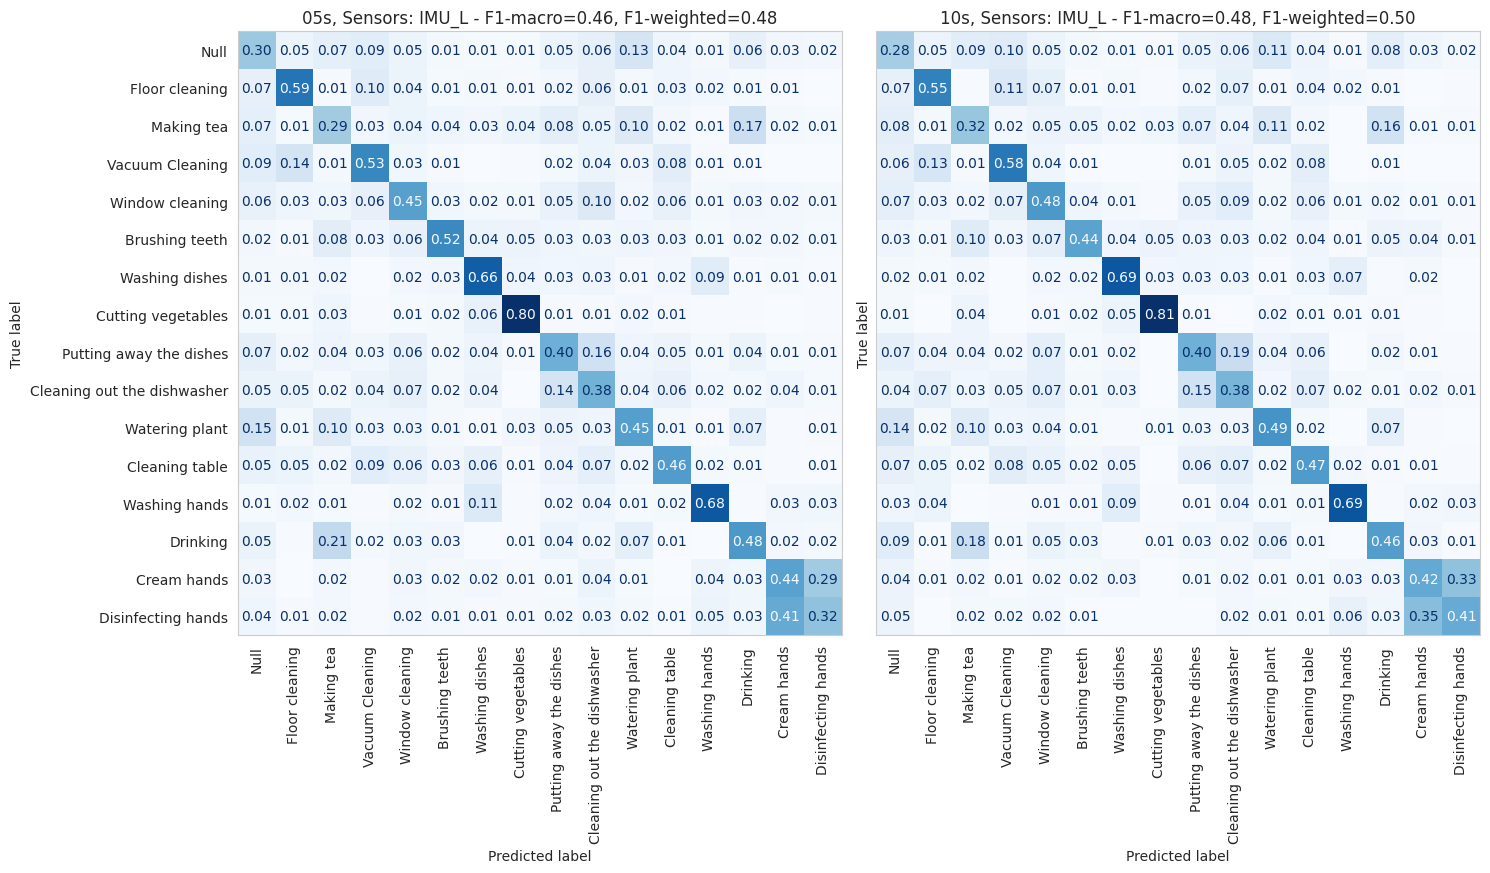

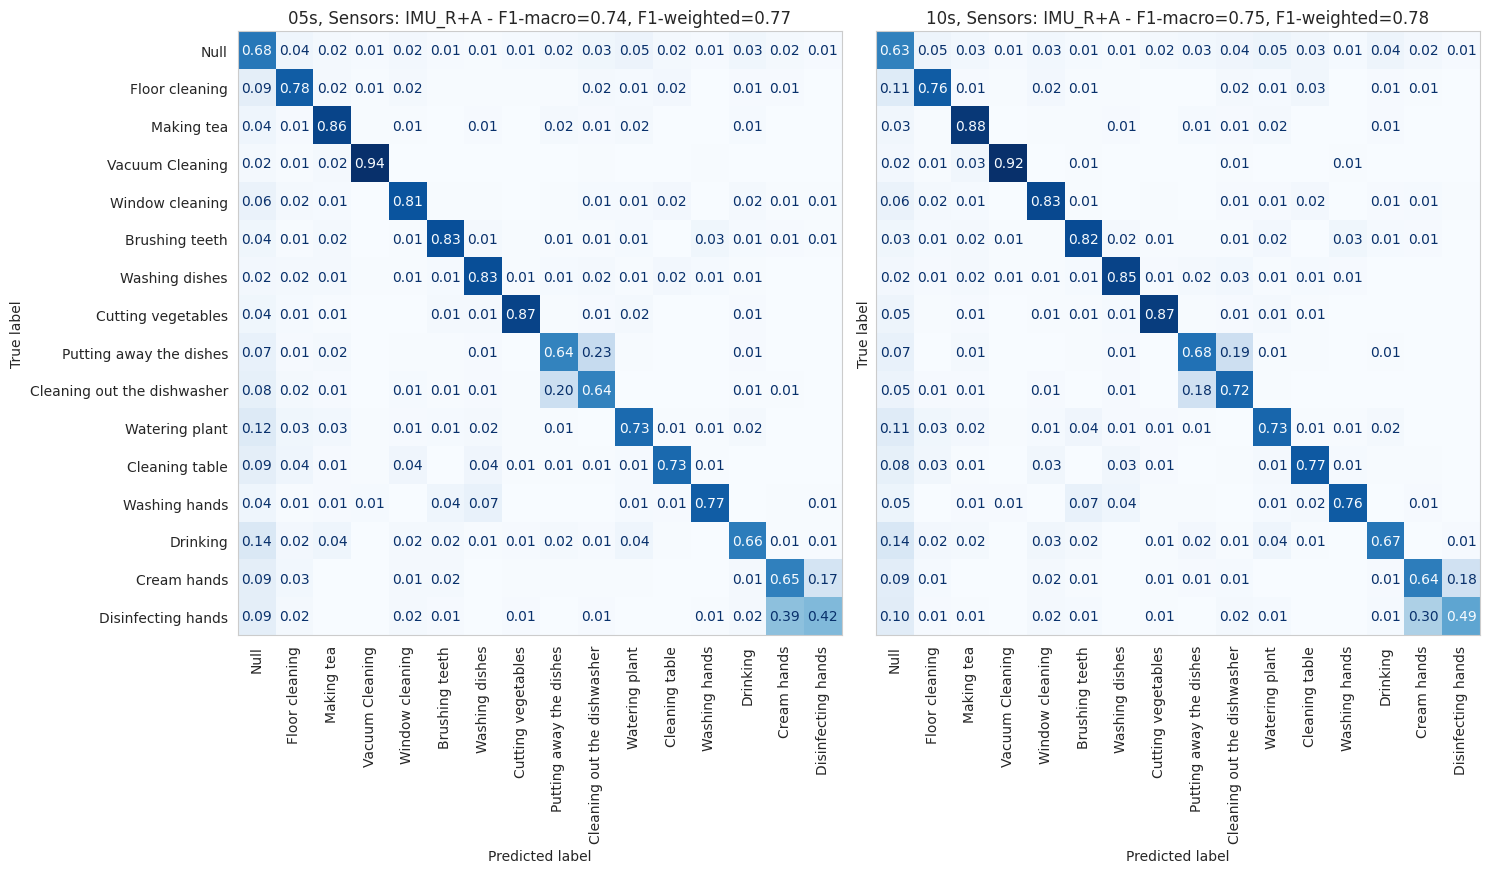

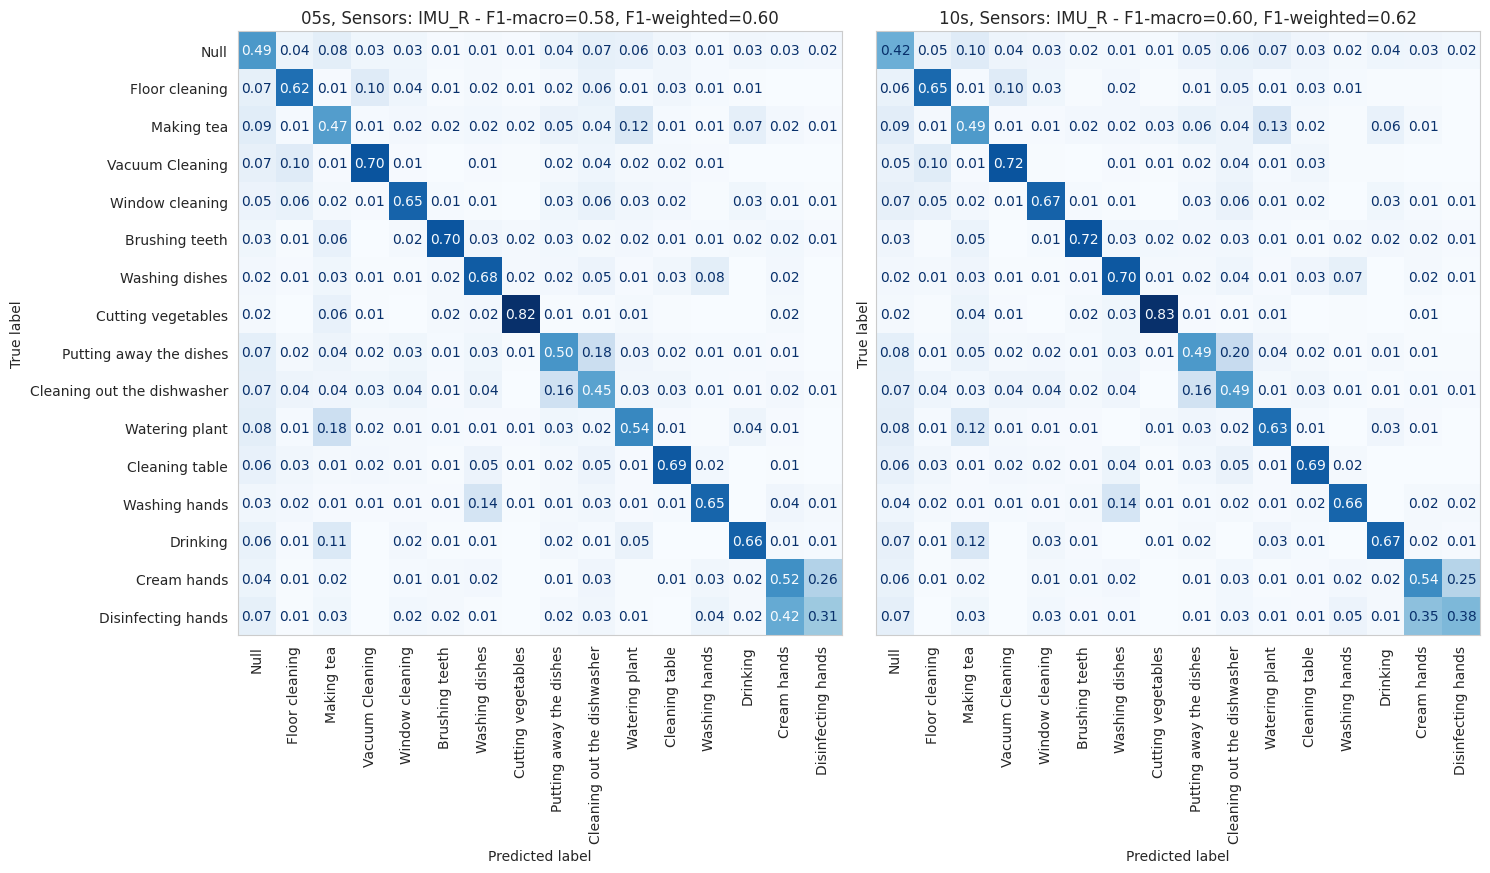

In [49]:
os.makedirs("conf_plots", exist_ok=True)
i = -1

sorted_data = sorted(zip(preds, labels, orders, cfgs), key=lambda x: x[3])

preds, labels, orders, cfgs = map(list, zip(*sorted_data))

for (pred, true, order, key) in zip(preds, labels, orders, cfgs):
    if i == -1:
        i = 1
        fig, axes = plt.subplots(1,2, sharey=True, figsize=(15,22))
    pred = le.inverse_transform(np.concat(pred))
    true = le.inverse_transform(np.concat(true))
    disp = ConfusionMatrixDisplay.from_predictions(
        true,
        pred,
        labels=label_order,          # <-- this is the key
        normalize="true",
        ax=axes[i],
        values_format=".2f",
        cmap=plt.cm.Blues,
        colorbar=False
    )

    for text, value in zip(disp.text_.ravel(), disp.confusion_matrix.ravel()):
        if value < 0.005:
            text.set_text('')
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=90)
    f1 = f1_score(true, pred, average="macro")
    f1w = f1_score(true, pred, average="weighted")
    key_text = key.split(";")[0].upper()
    axes[i].set_title(f"{['05', '10'][i]}s, Sensors: {key_text} - F1-macro={f1:.2f}, F1-weighted={f1w:.2f}")
    axes[i].grid(False)
    i -= 1

    if i == -1:
        plt.tight_layout()
        plt.savefig(f"conf_plots/conf_{key}.pdf", bbox_inches="tight")
        plt.show()